In [1]:
# Importing required modules
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Q-Learner Agent Implementation
class QLearner:
    def __init__(self, num_states, num_actions):
        self.EPSILON = 0.1
        self.ALPHA = 0.85
        self.GAMMA = 0.99
        self.num_actions = num_actions
        self.Q = np.zeros([num_states, self.num_actions])

    def select_action(self, state):
        # Epsilon-greedy action selection strategy
        if np.random.binomial(1, self.EPSILON) == 1:
            return np.random.choice(self.num_actions)
        else:
            return np.argmax(self.Q[state, :])

    def learn(self, state, action, reward, next_state):
        # Q-value temporal difference update rule
        self.Q[state, action] += self.ALPHA * (
            reward + self.GAMMA * np.max(self.Q[next_state, :]) - self.Q[state, action]
        )

    def decay_exploration(self, episode):
        self.EPSILON /= (episode + 1)


# Cliff Walking Gridworld Environment Implementation
class CliffWalking:
    def __init__(self, height, width):
        self.height = height
        self.width = width
        self.observation_space = self.height * self.width
        self.action_space = ["U", "D", "L", "R"]  # Up, Down, Left, Right
        self.num_actions = len(self.action_space)

        self.current_pos = [self.height - 1, 0]

        self.grid = np.array(range(self.observation_space), dtype='U16').reshape(self.height, self.width)
        self.state_mapper = np.array(range(self.observation_space)).reshape(self.height, self.width)
        self.grid[:, :] = " "
        self.grid[self.height - 1, 1:self.width - 1] = "X"  # Cliff region
        self.grid[self.height - 1, 0] = "*"                 # Start state
        self.grid[self.height - 1, self.width - 1] = "G"     # Goal state

    def step(self, action):
        # Clear previous position marker
        self.grid[self.current_pos[0], self.current_pos[1]] = " "

        # Compute new position based on action
        if (self.action_space[action] == "U" and self.current_pos[0] > 0):
            self.current_pos[0] -= 1
        elif (self.action_space[action] == "D" and self.current_pos[0] < self.height - 1):
            self.current_pos[0] += 1
        elif (self.action_space[action] == "L" and self.current_pos[1] > 0):
            self.current_pos[1] -= 1
        elif (self.action_space[action] == "R" and self.current_pos[1] < self.width - 1):
            self.current_pos[1] += 1

        next_state = self.state_mapper[self.current_pos[0], self.current_pos[1]]

        # Calculate reward structure
        reward = -100 if (self.grid[self.current_pos[0], self.current_pos[1]] == "X") else -1

        # Check episode termination condition
        done = True if (
            self.grid[self.current_pos[0], self.current_pos[1]] in ["X", "G"]
        ) else False

        # Mark new position if episode is continuing
        if not done:
            self.grid[self.current_pos[0], self.current_pos[1]] = "*"

        return next_state, reward, done, ""

    def reset(self):
        self.grid[self.height - 1, 0] = "*"
        self.current_pos = [self.height - 1, 0]
        return self.state_mapper[self.height - 1, 0]

    def render(self):
        print(self.grid)

# %%
# Training Simulation Loop
env = CliffWalking(4, 12)

num_episodes = 200
max_steps = 100

agent = QLearner(env.observation_space, env.num_actions)
total_rewards = np.zeros(num_episodes)

for i in range(num_episodes):
    state = env.reset()

    for j in range(max_steps):
        env.render()

        action = agent.select_action(state)
        next_state, reward, done, info = env.step(action)

        agent.learn(state, action, reward, next_state)

        total_rewards[i] += reward
        state = next_state

        if done:
            agent.decay_exploration(i)
            break

[[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 ['*' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'G']]
[[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 ['*' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'G']]
[[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 ['*' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'G']]
[['*' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'X' 'G']]
[[' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 ['*' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' 'X' 'X' 'X' 'X' 'X' '

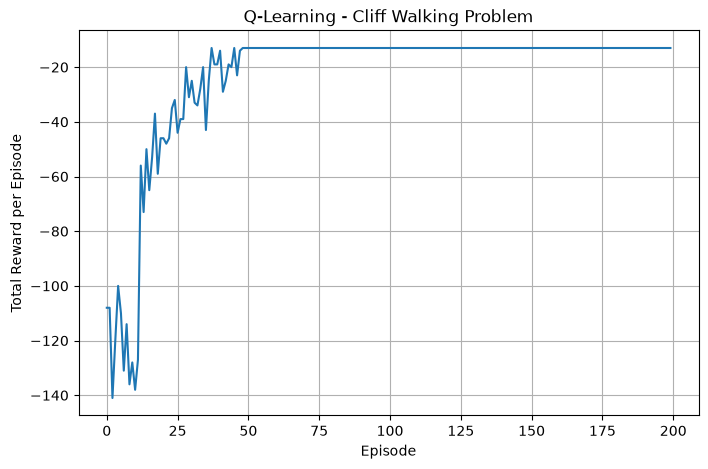

In [4]:
# Plotting Episode Rewards Convergence
x = np.arange(0, num_episodes, 1)
y = np.array(total_rewards)

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.xlabel('Episode')
plt.ylabel('Total Reward per Episode')
plt.title('Q-Learning - Cliff Walking Problem')
plt.grid(True)
plt.show()